# FINAL TEST-SET EVALUATION -- Experiment 003 (Final Training)

## Objective

**Final, independent test-set evaluation** of the checkpoint produced by
experiment 003 (`notebooks/03_training/03_final_training.ipynb`, 30-epoch
RadImageNet-initialized run on all 1000 labeled training images, learning
rate 1e-3 selected by experiment 002, no validation split, final-epoch
checkpoint). This notebook:

- loads `experiments/003_final_training/checkpoint/final.pt` from disk into
  a **fresh** `OhashiResNet50` instance (no reliance on any training
  notebook's in-memory state),
- uses **only** the 300-image held-out LDCT-IQAC test set (never train or
  validation data),
- runs inference exactly once, with `model.eval()` / `torch.no_grad()`,
- computes and saves metrics/predictions/figures under `results/`,
- compares experiment 003's raw test metrics against experiment 001's
  already-measured raw test metrics (both evaluated on the identical,
  untouched 300-image test set),
- performs **no retraining, no fine-tuning, no architecture change, no
  preprocessing change, no hyperparameter tuning, and no checkpoint/model
  selection of any kind.**

This is an **Ohashi-style RadImageNet ResNet50 CT-IQA model adapted to
LDCT-IQAC** -- not an exact reproduction of the original paper (which used
synthetic Gaussian degradation and VIF labels on its own dataset; see
`docs/replication/dataset_adaptation.md`). Numbers below are **not**
compared directly against the paper's reported PLCC/SROCC as if
equivalent.

**TEST SET USED ONLY FOR FINAL EVALUATION.**

## Configuration

Loaded from the same `configs/*.yaml` files as training, via
`ExperimentConfig.from_yaml_files()`, with `experiment_dir` overridden to
point at experiment 003 (`configs/training.yaml`'s own `experiment_dir`
still points at experiment 001, unrelated to this evaluation).
Architecture-relevant fields (`dropout_p`, `in_channels`, `image_size`) are
cross-checked against what the checkpoint itself recorded at training time
(Section "Checkpoint" below) -- if they ever disagreed, that would mean the
current config silently drifted from what actually produced this
checkpoint.

In [1]:
import os
import sys
from pathlib import Path

_cwd = Path.cwd()
_repo_root = _cwd if (_cwd / "data").exists() else _cwd.parent.parent  # notebooks/04_evaluation/ -> repo root
os.chdir(_repo_root)
if str(_repo_root / "src") not in sys.path:
    sys.path.insert(0, str(_repo_root / "src"))  # only needed until `pip install -e .` is run
print(f"repo root: {_repo_root}")

repo root: C:\Users\surya\OneDrive\Desktop\Deep-Learning-for-CT-Image-Quality-Assessment


In [2]:
import csv
import json

import matplotlib.pyplot as plt
import numpy as np
import torch

from ct_iqa.config import ExperimentConfig
from ct_iqa.data.ldct_iqac import LDCTIQACDataset, SCORE_MIN, SCORE_MAX, denormalize_score, normalize_score
from ct_iqa.data.loader import build_test_dataloader
from ct_iqa.evaluation.metrics import compute_metrics
from ct_iqa.models.ohashi_resnet50 import OhashiResNet50
from ct_iqa.training.checkpointing import best_checkpoint_path, load_checkpoint, load_checkpoint_metadata

EXPERIMENT_NAME = "003_final_training"
CHECKPOINT_FILENAME = "final.pt"

config = ExperimentConfig.from_yaml_files(
    experiment_dir=f"experiments/{EXPERIMENT_NAME}",
    device="cuda" if torch.cuda.is_available() else "cpu",
)
print(f"experiment_dir : {config.experiment_dir}")
print(f"checkpoint_dir : {config.checkpoint_dir}")
config

experiment_dir : experiments/003_final_training
checkpoint_dir : experiments\003_final_training\checkpoint


ExperimentConfig(seed=42, batch_size=64, epochs=30, learning_rate=0.001, optimizer='adam', loss='mse', image_size=224, selection_metric='plcc', dropout_p=0.5, in_channels=1, train_image_dir='data/raw/ldct_iqac/train/image', train_json_path='data/labels/ldct_iqac/train.json', test_image_dir='data/raw/ldct_iqac/test/images', test_json_path='data/labels/ldct_iqac/test.json', dataset_name='ldct_iqac', architecture='ohashi_resnet50', val_fraction=0.1, radimagenet_weights_path='weights/pretrained/radimagenet/resnet50/radimagenet_resnet50_backbone.pt', experiment_dir='experiments/003_final_training', device='cpu')

## Checkpoint

Load `experiments/003_final_training/checkpoint/final.pt` into a **fresh**
`OhashiResNet50` instance -- this notebook has no dependency on any training
notebook's process/memory, and does not reuse experiment 003's in-memory
training model or any previous evaluation model. Cross-check the
checkpoint's recorded config against the current `configs/*.yaml` before
trusting that "the same architecture" is actually being evaluated, and
confirm this is the final-epoch checkpoint (`checkpoint_type ==
"final_epoch"`), not a validation-selected `best.pt`.

The RadImageNet-pretrained backbone was already used to *initialize*
experiment 003's training run (see
`experiments/003_final_training/README.md`: 265/318 backbone keys matched,
0 unexpected); this checkpoint's `model_state_dict` holds the resulting
*trained* parameters. Loading it here does not re-initialize from
RadImageNet or fall back to it -- `load_checkpoint` only ever loads
`final.pt`'s own `model_state_dict`.

In [3]:
checkpoint_path = best_checkpoint_path(config.checkpoint_dir, filename=CHECKPOINT_FILENAME)
assert checkpoint_path.exists(), f"no checkpoint found at {checkpoint_path} -- run the final-training notebook first"

metadata = load_checkpoint_metadata(config.checkpoint_dir, map_location=config.device, filename=CHECKPOINT_FILENAME)
checkpoint_config = metadata.get("config", {})

print("=== CHECKPOINT SUMMARY ===")
print(f"path            : {checkpoint_path}")
print(f"epoch           : {metadata.get('epoch')}  (0-indexed; 29 == completed epoch 30, the FINAL epoch)")
print(f"checkpoint_type : {metadata.get('checkpoint_type')!r}")
print(f"seed            : {metadata.get('seed')}")
print(f"optimizer state present: {'optimizer_state_dict' in metadata}")

assert metadata.get("checkpoint_type") == "final_epoch", (
    f"expected the final-epoch checkpoint, got checkpoint_type={metadata.get('checkpoint_type')!r}"
)
assert metadata.get("epoch") == 29, f"expected epoch 29 (0-indexed, completed epoch 30), got {metadata.get('epoch')}"
print("Confirmed: this is experiment 003's final-epoch (epoch 30) checkpoint, not a best-validation checkpoint.")

print()
print("=== ARCHITECTURE CONSISTENCY CHECK (checkpoint's config vs. current configs/*.yaml) ===")
_architecture_ok = True
for key in ["dropout_p", "in_channels", "image_size"]:
    current_value = getattr(config, key)
    checkpoint_value = checkpoint_config.get(key)
    match = current_value == checkpoint_value
    _architecture_ok &= match
    print(f"  {key:<12}: checkpoint={checkpoint_value!r}  current={current_value!r}  match={match}")
assert _architecture_ok, "architecture-relevant configuration has changed since this checkpoint was trained"
assert checkpoint_config.get("dropout_p") == 0.5, "expected dropout_p=0.5 (experiment 003's documented configuration)"
assert checkpoint_config.get("image_size") == 224, "expected image_size=224"
assert checkpoint_config.get("in_channels") == 1, "expected in_channels=1"
print("No unexpected architecture mismatch detected.")

=== CHECKPOINT SUMMARY ===
path            : experiments\003_final_training\checkpoint\final.pt
epoch           : 29  (0-indexed; 29 == completed epoch 30, the FINAL epoch)
checkpoint_type : 'final_epoch'
seed            : 42
optimizer state present: True
Confirmed: this is experiment 003's final-epoch (epoch 30) checkpoint, not a best-validation checkpoint.

=== ARCHITECTURE CONSISTENCY CHECK (checkpoint's config vs. current configs/*.yaml) ===
  dropout_p   : checkpoint=0.5  current=0.5  match=True
  in_channels : checkpoint=1  current=1  match=True
  image_size  : checkpoint=224  current=224  match=True
No unexpected architecture mismatch detected.


In [4]:
model = OhashiResNet50(dropout_p=config.dropout_p, in_channels=config.in_channels)  # fresh instance, no reuse
load_checkpoint(model, config.checkpoint_dir, map_location=config.device, filename=CHECKPOINT_FILENAME)  # loads model_state_dict only
model.to(config.device)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"model loaded successfully from a fresh process/instance. total parameters: {total_params:,}")
print("(RadImageNet-compatibility was already verified when this checkpoint's backbone was trained --")
print(" see weights/pretrained/radimagenet/resnet50/README.md and experiments/003_final_training/README.md;")
print(" loading these POST-TRAINING weights back into the identical architecture without a state_dict")
print(" error is itself a structural consistency check. No reinitialization from RadImageNet and no")
print(" ImageNet fallback occurred -- the loaded parameters are exactly final.pt's trained weights.)")

model loaded successfully from a fresh process/instance. total parameters: 23,510,081
(RadImageNet-compatibility was already verified when this checkpoint's backbone was trained --
 see weights/pretrained/radimagenet/resnet50/README.md and experiments/003_final_training/README.md;
 loading these POST-TRAINING weights back into the identical architecture without a state_dict
 error is itself a structural consistency check. No reinitialization from RadImageNet and no
 ImageNet fallback occurred -- the loaded parameters are exactly final.pt's trained weights.)


## Test Data

**Only** the held-out LDCT-IQAC test split is used below --
`data/raw/ldct_iqac/test/images/` + `data/labels/ldct_iqac/test.json`.
Neither the training split nor any validation subset is loaded anywhere in
this notebook -- no training `Dataset`/`DataLoader` and no validation
`Dataset`/`DataLoader` are constructed.

In [5]:
test_loader = build_test_dataloader(config)
test_dataset = test_loader.dataset
print(f"test images : {len(test_dataset)}  (expected 300)")
assert len(test_dataset) == 300, f"expected 300 test images, found {len(test_dataset)}"

# LDCTIQACDataset's own construction already enforces: every image has
# exactly one label and vice versa (see src/ct_iqa/data/ldct_iqac.py) --
# reaching this line at all means that invariant already held. The checks
# below cover what construction does NOT already enforce.
import hashlib
from PIL import Image

filenames = [s.filename for s in test_dataset.samples]
assert len(filenames) == len(set(filenames)), "duplicate filenames within the test set"

hashes = {}
duplicate_content = []
for sample in test_dataset.samples:
    with Image.open(sample.path) as im:
        digest = hashlib.md5(np.array(im).tobytes()).hexdigest()
    if digest in hashes:
        duplicate_content.append((sample.filename, hashes[digest]))
    else:
        hashes[digest] = sample.filename

print(f"duplicate filenames        : {len(filenames) - len(set(filenames))}")
print(f"duplicate image content    : {len(duplicate_content)} {duplicate_content[:5]}")
print(f"labels                     : {len(test_dataset)} (one per image, enforced by LDCTIQACDataset construction)")
assert len(duplicate_content) == 0, "duplicate image content found within the test set"
print("Test set integrity confirmed: 300 images, 300 labels, no missing/orphan labels, no duplicates.")

test images : 300  (expected 300)


duplicate filenames        : 0
duplicate image content    : 0 []
labels                     : 300 (one per image, enforced by LDCTIQACDataset construction)
Test set integrity confirmed: 300 images, 300 labels, no missing/orphan labels, no duplicates.


## Test-Set Independence Check (before computing any metric)

Confirmed from the experiment record (`experiments/003_final_training/`,
`experiments/002_learning_rate_search/`, `experiments/001_resnet50_baseline/`)
-- not re-derived here, since these are facts about *how the checkpoint was
produced*, not something this evaluation notebook can measure itself:

- The final checkpoint (`final.pt`) was created by experiment 003's
  training run, which completed **before** this evaluation notebook runs.
- No test metric influenced training: experiment 003's training loop never
  constructed a test `Dataset`/`DataLoader` (see
  `experiments/003_final_training/README.md`, "Test set status").
- No test metric influenced learning-rate selection: experiment 002's LR
  search used only the 900/100 train/validation split (see
  `experiments/002_learning_rate_search/README.md`, "Test set status").
- No test metric influenced checkpoint selection: experiment 003 has no
  validation split and therefore no validation-based "best epoch" selection
  -- `final.pt` is simply the epoch-30 (final) model, an unconditional
  choice made before any test-set number existed.
- No test metric influenced preprocessing or model architecture: both are
  fixed by `src/ct_iqa/` and `configs/*.yaml`, unchanged across experiments
  001/002/003 and this evaluation.

**TEST SET USED ONLY FOR FINAL EVALUATION.**

## Inference

Exactly the trained pipeline, gradients disabled:
`LDCT-IQAC image -> center crop 224x224 -> [0,1]->[-1,1] -> (model
replicates grayscale to 3 channels internally) -> ResNet50 -> Dropout ->
Linear -> Sigmoid`. No new preprocessing, no resizing, no normalization
change, no augmentation -- `test_loader` is built by the same
`ct_iqa.data.loader.build_test_dataloader` every training notebook uses.

Ground-truth and prediction are recorded in both scales: the model's
native normalized `[0,1]` Sigmoid output, and the original `[0,4]`
LDCT-IQAC score scale via `ct_iqa.data.ldct_iqac.denormalize_score`
(`x * (SCORE_MAX - SCORE_MIN) + SCORE_MIN` = `x * 4` here, since
`SCORE_MIN = 0`) -- the same function used during training, not a new
formula. The Sigmoid head guarantees predictions stay within the open
interval `(0, 4)` by construction, so no clipping is applied; if any
prediction were observed outside `[0, 4]` it would be reported below, not
silently corrected.

In [6]:
records = []
with torch.no_grad():
    offset = 0
    for images, raw_scores in test_loader:
        images = images.to(config.device)
        predictions_normalized = model(images)  # Sigmoid output, [0,1]

        batch_size = images.shape[0]
        batch_filenames = filenames[offset : offset + batch_size]
        offset += batch_size

        gt_normalized = normalize_score(raw_scores)
        pred_raw_scale = denormalize_score(predictions_normalized.cpu())

        for fn, gt_r, gt_n, pred_n, pred_r in zip(
            batch_filenames, raw_scores.tolist(), gt_normalized.tolist(),
            predictions_normalized.cpu().tolist(), pred_raw_scale.tolist(),
        ):
            records.append({
                "filename": fn,
                "ground_truth_score": gt_r,
                "ground_truth_normalized": gt_n,
                "prediction_normalized": pred_n,
                "prediction_score": pred_r,
            })

assert len(records) == 300, f"expected 300 inference records, got {len(records)}"
print(f"inference complete: {len(records)} predictions collected.")
print(f"example record: {records[0]}")

out_of_range = [r for r in records if not (SCORE_MIN <= r["prediction_score"] <= SCORE_MAX)]
print(f"predictions outside [{SCORE_MIN},{SCORE_MAX}] after inverse transform: {len(out_of_range)}")
if out_of_range:
    print("  (reported, not corrected):", out_of_range[:5])

inference complete: 300 predictions collected.
example record: {'filename': 'test000.tiff', 'ground_truth_score': 2.6666667461395264, 'ground_truth_normalized': 0.6666666865348816, 'prediction_normalized': 0.5228874087333679, 'prediction_score': 2.0915496349334717}
predictions outside [0.0,4.0] after inverse transform: 0


## Primary Final Test Metrics (RAW model output, no calibration)

Computed with `ct_iqa.evaluation.metrics.compute_metrics` on **all 300**
test images (no subset, no outlier removal, no favorable-sample selection)
-- PLCC, SROCC, KROCC on the original `[0, 4]` LDCT-IQAC score scale
(correlation coefficients are scale-invariant; MSE is reported on both
scales for clarity). MAE/RMSE are computed here as plain descriptive
statistics from the same predictions/targets, not as a new evaluation
methodology.

In [7]:
gt_raw_arr = np.array([r["ground_truth_score"] for r in records])
pred_raw_arr = np.array([r["prediction_score"] for r in records])
gt_norm_arr = np.array([r["ground_truth_normalized"] for r in records])
pred_norm_arr = np.array([r["prediction_normalized"] for r in records])

raw_scale_metrics = compute_metrics(gt_raw_arr, pred_raw_arr)  # PLCC/SROCC/KROCC scale-invariant; MSE in [0,4]^2 units
normalized_scale_mse = compute_metrics(gt_norm_arr, pred_norm_arr)["mse"]  # same MSE / 16, in [0,1]^2 units

mae_raw = float(np.mean(np.abs(pred_raw_arr - gt_raw_arr)))
rmse_raw = float(np.sqrt(raw_scale_metrics["mse"]))

print("=== FINAL RAW TEST METRICS (original [0,4] score scale, n=300) ===")
print(f"  PLCC : {raw_scale_metrics['plcc']:.4f}")
print(f"  SROCC: {raw_scale_metrics['srocc']:.4f}")
print(f"  KROCC: {raw_scale_metrics['krocc']:.4f}")
print(f"  MSE  : {raw_scale_metrics['mse']:.4f}   (score-unit^2, scale [0,4])")
print(f"  MAE  : {mae_raw:.4f}   (score units, scale [0,4])")
print(f"  RMSE : {rmse_raw:.4f}   (score units, scale [0,4])")
print()
print(f"  MSE (normalized [0,1] scale, for reference against training-time loss): {normalized_scale_mse:.6f}")

=== FINAL RAW TEST METRICS (original [0,4] score scale, n=300) ===
  PLCC : 0.8490
  SROCC: 0.8525
  KROCC: 0.6611
  MSE  : 0.4474   (score-unit^2, scale [0,4])
  MAE  : 0.5195   (score units, scale [0,4])
  RMSE : 0.6689   (score units, scale [0,4])

  MSE (normalized [0,1] scale, for reference against training-time loss): 0.027966


## Prediction Distribution Analysis

Compared against the ground-truth distribution, on the `[0, 4]` raw
score scale. No prediction is altered based on this analysis; the analysis
below only reports what is observed (collapse, saturation, systematic
bias) -- nothing is corrected here.

In [8]:
def describe(arr, name):
    return {
        "name": name, "min": float(arr.min()), "max": float(arr.max()),
        "mean": float(arr.mean()), "median": float(np.median(arr)), "std": float(arr.std()),
    }

pred_stats = describe(pred_raw_arr, "prediction")
gt_stats = describe(gt_raw_arr, "ground_truth")

print(f"{'':<12}{'min':>8}{'max':>8}{'mean':>8}{'median':>8}{'std':>8}")
for s in [gt_stats, pred_stats]:
    print(f"{s['name']:<12}{s['min']:>8.3f}{s['max']:>8.3f}{s['mean']:>8.3f}{s['median']:>8.3f}{s['std']:>8.3f}")

bias = pred_stats["mean"] - gt_stats["mean"]
print()
print(f"mean prediction - mean ground truth (bias): {bias:+.4f}")
print(f"prediction std / ground-truth std          : {pred_stats['std'] / gt_stats['std']:.4f}  (1.0 = same spread; << 1 suggests collapse toward the mean)")
print(f"predictions at/near SCORE_MIN ({SCORE_MIN}) : {int((pred_raw_arr <= SCORE_MIN + 0.05).sum())} / {len(pred_raw_arr)}")
print(f"predictions at/near SCORE_MAX ({SCORE_MAX}) : {int((pred_raw_arr >= SCORE_MAX - 0.05).sum())} / {len(pred_raw_arr)}")
print()
print("Note: the Sigmoid output head guarantees predictions stay within (0, 1) normalized")
print("/ (0, 4) raw scale by construction -- no clipping is applied or needed; the actual")
print(f"observed range above ([{pred_stats['min']:.4f}, {pred_stats['max']:.4f}]) confirms this empirically.")

                 min     max    mean  median     std
ground_truth   0.000   4.000   2.131   2.167   1.087
prediction     0.024   3.689   1.791   1.752   0.878

mean prediction - mean ground truth (bias): -0.3396
prediction std / ground-truth std          : 0.8076  (1.0 = same spread; << 1 suggests collapse toward the mean)
predictions at/near SCORE_MIN (0.0) : 3 / 300
predictions at/near SCORE_MAX (4.0) : 0 / 300

Note: the Sigmoid output head guarantees predictions stay within (0, 1) normalized
/ (0, 4) raw scale by construction -- no clipping is applied or needed; the actual
observed range above ([0.0235, 3.6891]) confirms this empirically.


## Residual Analysis

`residual = prediction - ground_truth`, on the `[0, 4]` raw score scale.
No difficult example is removed.

In [9]:
residuals = pred_raw_arr - gt_raw_arr

residual_stats = {
    "mean": float(residuals.mean()),
    "median": float(np.median(residuals)),
    "std": float(residuals.std()),
    "min": float(residuals.min()),
    "max": float(residuals.max()),
}
print("=== RESIDUAL STATISTICS (prediction - ground_truth, [0,4] scale, n=300) ===")
for k, v in residual_stats.items():
    print(f"  {k:<8}: {v:+.4f}")

# Residuals across quality-score ranges (quartile bins of ground truth)
bin_edges = np.quantile(gt_raw_arr, [0.0, 0.25, 0.5, 0.75, 1.0])
bin_edges[0] -= 1e-6  # include the minimum in the first bin
bin_idx = np.digitize(gt_raw_arr, bin_edges[1:-1], right=True)
print()
print("=== RESIDUALS BY GROUND-TRUTH QUARTILE ===")
for b in range(4):
    mask = bin_idx == b
    if mask.sum() == 0:
        continue
    print(
        f"  gt in [{bin_edges[b]:.2f}, {bin_edges[b+1]:.2f}]  n={int(mask.sum()):3d}  "
        f"mean residual={residuals[mask].mean():+.4f}  std={residuals[mask].std():.4f}"
    )

=== RESIDUAL STATISTICS (prediction - ground_truth, [0,4] scale, n=300) ===
  mean    : -0.3396
  median  : -0.2732
  std     : +0.5763
  min     : -2.2078
  max     : +1.1197

=== RESIDUALS BY GROUND-TRUTH QUARTILE ===
  gt in [-0.00, 1.17]  n= 82  mean residual=+0.1079  std=0.3698
  gt in [1.17, 2.17]  n= 76  mean residual=-0.3043  std=0.4989
  gt in [2.17, 3.00]  n= 77  mean residual=-0.4097  std=0.4505
  gt in [3.00, 4.00]  n= 65  mean residual=-0.8625  std=0.5436


## Prediction Artifact

Per-image predictions saved as CSV -- one row per test image (exactly
300).

In [10]:
predictions_csv_path = Path(f"results/predictions/{EXPERIMENT_NAME}_test_predictions.csv")
predictions_csv_path.parent.mkdir(parents=True, exist_ok=True)
with predictions_csv_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=[
        "filename", "ground_truth_score", "prediction_score",
        "ground_truth_normalized", "prediction_normalized",
    ])
    writer.writeheader()
    writer.writerows(records)
assert sum(1 for _ in predictions_csv_path.open(encoding="utf-8")) - 1 == 300, "expected exactly 300 prediction rows"
print(f"saved {len(records)} predictions to {predictions_csv_path}")

saved 300 predictions to results\predictions\003_final_training_test_predictions.csv


## Experiment 001 vs. Experiment 003 -- Final Comparison

Both models were evaluated on the **identical, untouched** 300-image
LDCT-IQAC test set, so this comparison is scientifically meaningful (same
dataset, same architecture, same preprocessing -- different training
protocol). Experiment 001's numbers below are the already-measured,
already-persisted values from
`experiments/001_resnet50_baseline/README.md` /
`results/metrics/001_resnet50_baseline_test_metrics.json` -- they are not
recomputed here, only used as a fixed reference point.

| | Experiment 001 | Experiment 003 |
|---|---|---|
| Training data | 900/1000 (100 held out for validation) | all 1000/1000 |
| Learning rate | 1e-3 (paper default, not searched) | 1e-3 (selected by experiment 002's search) |
| Checkpoint | best-validation-PLCC epoch (20, 0-indexed; `checkpoint_type="best_plcc"` -- see docs/internal/decisions/README.md, 2026-09-14) | final epoch (29, 0-indexed / epoch 30) |

No statistical significance test is implemented in this project, so this
section reports **empirical differences only** -- it does not claim
statistical significance for any difference below.

In [11]:
EXPERIMENT_001_RAW_METRICS = {
    "PLCC": 0.8667,
    "SROCC": 0.8699,
    "KROCC": 0.6816,
    "MSE": 0.3291,
    "MAE": 0.4815,
    "RMSE": 0.5736,
}

experiment_003_raw_metrics = {
    "PLCC": raw_scale_metrics["plcc"],
    "SROCC": raw_scale_metrics["srocc"],
    "KROCC": raw_scale_metrics["krocc"],
    "MSE": raw_scale_metrics["mse"],
    "MAE": mae_raw,
    "RMSE": rmse_raw,
}

comparison_rows = []
print(f"{'Metric':<8}{'Exp 001':>12}{'Exp 003':>12}{'Difference':>14}")
for metric_name in ["PLCC", "SROCC", "KROCC", "MSE", "MAE", "RMSE"]:
    exp001_value = EXPERIMENT_001_RAW_METRICS[metric_name]
    exp003_value = experiment_003_raw_metrics[metric_name]
    diff = exp003_value - exp001_value
    comparison_rows.append({
        "metric": metric_name,
        "experiment_001_baseline": exp001_value,
        "experiment_003_final": exp003_value,
        "absolute_difference": diff,
    })
    print(f"{metric_name:<8}{exp001_value:>12.4f}{exp003_value:>12.4f}{diff:>+14.4f}")

comparison_csv_path = Path("results/tables/001_vs_003_final_comparison.csv")
comparison_csv_path.parent.mkdir(parents=True, exist_ok=True)
with comparison_csv_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["metric", "experiment_001_baseline", "experiment_003_final", "absolute_difference"])
    writer.writeheader()
    writer.writerows(comparison_rows)
print()
print(f"saved comparison table to {comparison_csv_path}")
print()
print("No statistical significance test is implemented in this project -- the table above")
print("reports empirical differences only, not significance.")

Metric       Exp 001     Exp 003    Difference
PLCC          0.8667      0.8490       -0.0177
SROCC         0.8699      0.8525       -0.0174
KROCC         0.6816      0.6611       -0.0205
MSE           0.3291      0.4474       +0.1183
MAE           0.4815      0.5195       +0.0380
RMSE          0.5736      0.6689       +0.0953

saved comparison table to results\tables\001_vs_003_final_comparison.csv

No statistical significance test is implemented in this project -- the table above
reports empirical differences only, not significance.


## Metrics Artifact

In [12]:
metrics_record = {
    "experiment_name": EXPERIMENT_NAME,
    "checkpoint": str(checkpoint_path),
    "checkpoint_epoch": metadata.get("epoch"),
    "checkpoint_type": metadata.get("checkpoint_type"),
    "dataset": "LDCT-IQAC test split",
    "n_test_samples": len(records),
    "model": "RadImageNet-pretrained ResNet50 -> GAP -> Dropout(0.5) -> Linear(2048,1) -> Sigmoid (Ohashi-style, adapted to LDCT-IQAC)",
    "learning_rate": checkpoint_config.get("learning_rate"),
    "epochs": checkpoint_config.get("epochs"),
    "batch_size": checkpoint_config.get("batch_size"),
    "seed": metadata.get("seed"),
    "evaluation_scale": "raw LDCT-IQAC score scale [0,4] for PLCC/SROCC/KROCC/MSE/MAE/RMSE; normalized [0,1] MSE also reported",
    "PLCC": raw_scale_metrics["plcc"],
    "SROCC": raw_scale_metrics["srocc"],
    "KROCC": raw_scale_metrics["krocc"],
    "MSE": raw_scale_metrics["mse"],
    "MAE": mae_raw,
    "RMSE": rmse_raw,
    "MSE_normalized_0_1_scale": normalized_scale_mse,
    "prediction_distribution": {"ground_truth": gt_stats, "prediction": pred_stats},
    "residuals": residual_stats,
    "calibrated": None,
    "calibration_note": (
        "Calibrated final-test evaluation was not performed because no non-test "
        "calibration protocol has been established. "
        "ct_iqa.evaluation.calibration.five_parameter_logistic_fit fits its parameters "
        "directly on whatever (y_pred, y_true) pair it is given. Fitting it on the test "
        "set itself and reporting the resulting test metrics would be circular -- the "
        "calibration would be optimized against the exact data being evaluated. No "
        "validation-set-based (non-test) calibration protocol is implemented in this "
        "project, so raw (uncalibrated) results are reported as primary and final."
    ),
    "test_set_used_only_for_final_evaluation": True,
}
metrics_json_path = Path(f"results/metrics/{EXPERIMENT_NAME}_test_metrics.json")
metrics_json_path.parent.mkdir(parents=True, exist_ok=True)
metrics_json_path.write_text(json.dumps(metrics_record, indent=2))
print(f"saved metrics to {metrics_json_path}")

saved metrics to results\metrics\003_final_training_test_metrics.json


## Calibration -- NOT Fit on the Test Set

The Ohashi paper's evaluation methodology applies a five-parameter
logistic (5PL) mapping before computing PLCC/SROCC
(`ct_iqa.evaluation.calibration.five_parameter_logistic_fit`,
`docs/paper/evaluation.md`). **That function is NOT called with test-set
data anywhere in this notebook.**

`five_parameter_logistic_fit(y_pred, y_true)` fits its parameters directly
against whatever pair of arrays it is given via `scipy.optimize.curve_fit`
-- there is no held-out/non-test calibration protocol implemented anywhere
in this project (no "fit on validation, apply fixed mapping to test" path
exists in `src/ct_iqa/`, and experiment 003 has no validation split at all
to fit one against even if it existed). Fitting it directly on the test set
and then reporting the resulting test PLCC/SROCC would optimize the
calibration against the exact data being evaluated -- an optimistic, biased
estimate, not an unbiased one. No new calibration split is invented here.

**Calibrated final-test evaluation was not performed because no non-test
calibration protocol has been established. RAW final test results (above)
are reported as this evaluation's primary and only result.**

## Diagnostic Plots

Saved under `results/figures/` with a `003_final_training_` prefix --
experiment 001's figures (`001_resnet50_baseline_test_*`) are not
overwritten.

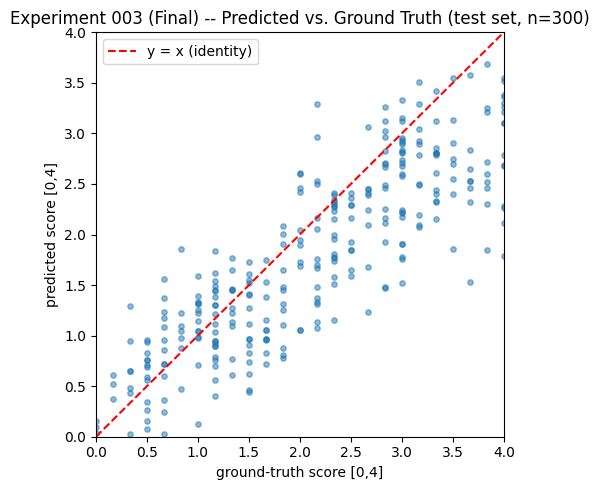

saved results\figures\003_final_training_test_pred_vs_gt.png


In [13]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(gt_raw_arr, pred_raw_arr, alpha=0.5, s=15)
ax.plot([SCORE_MIN, SCORE_MAX], [SCORE_MIN, SCORE_MAX], "r--", label="y = x (identity)")
ax.set_xlabel("ground-truth score [0,4]")
ax.set_ylabel("predicted score [0,4]")
ax.set_xlim(SCORE_MIN, SCORE_MAX)
ax.set_ylim(SCORE_MIN, SCORE_MAX)
ax.legend()
ax.set_title(f"Experiment 003 (Final) -- Predicted vs. Ground Truth (test set, n={len(records)})")
plt.tight_layout()
fig_path = Path("results/figures/003_final_training_test_pred_vs_gt.png")
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")

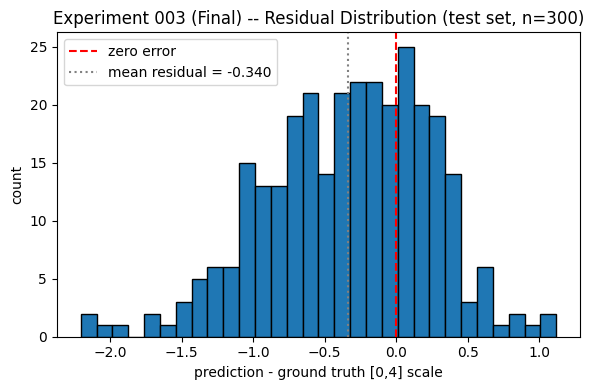

saved results\figures\003_final_training_test_residuals.png


In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(residuals, bins=30, edgecolor="black")
ax.axvline(0.0, color="red", linestyle="--", label="zero error")
ax.axvline(residuals.mean(), color="gray", linestyle=":", label=f"mean residual = {residuals.mean():+.3f}")
ax.set_xlabel("prediction - ground truth [0,4] scale")
ax.set_ylabel("count")
ax.set_title(f"Experiment 003 (Final) -- Residual Distribution (test set, n={len(records)})")
ax.legend()
plt.tight_layout()
fig_path = Path("results/figures/003_final_training_test_residuals.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")

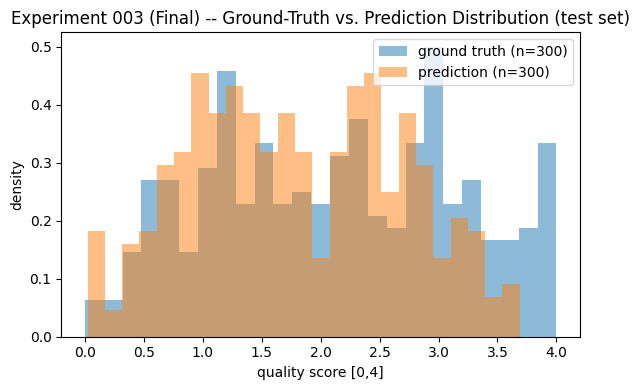

saved results\figures\003_final_training_test_score_distribution.png


In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(gt_raw_arr, bins=25, alpha=0.5, density=True, label=f"ground truth (n={len(gt_raw_arr)})")
ax.hist(pred_raw_arr, bins=25, alpha=0.5, density=True, label=f"prediction (n={len(pred_raw_arr)})")
ax.set_xlabel("quality score [0,4]")
ax.set_ylabel("density")
ax.set_title("Experiment 003 (Final) -- Ground-Truth vs. Prediction Distribution (test set)")
ax.legend()
plt.tight_layout()
fig_path = Path("results/figures/003_final_training_test_score_distribution.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")

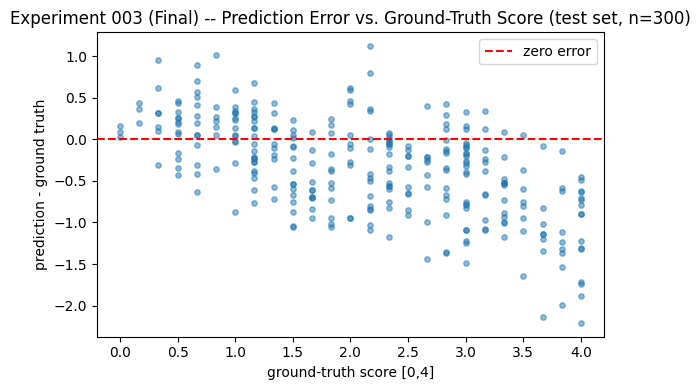

saved results\figures\003_final_training_test_error_vs_score.png


In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(gt_raw_arr, residuals, alpha=0.5, s=15)
ax.axhline(0.0, color="red", linestyle="--", label="zero error")
ax.set_xlabel("ground-truth score [0,4]")
ax.set_ylabel("prediction - ground truth")
ax.set_title(f"Experiment 003 (Final) -- Prediction Error vs. Ground-Truth Score (test set, n={len(records)})")
ax.legend()
plt.tight_layout()
fig_path = Path("results/figures/003_final_training_test_error_vs_score.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")

## Ohashi Relationship (contextual only -- not a numerical comparison)

This is an **Ohashi-style RadImageNet ResNet50** model **adapted to
LDCT-IQAC** -- NOT an exact reproduction of the original paper's
experiment.

| | Ohashi (paper) | This experiment |
|---|---|---|
| Label source | Synthetic degradation + VIF | LDCT-IQAC real radiologist quality score |
| Dataset | Paper's own (not obtained by this project) | LDCT-IQAC |
| Backbone | RadImageNet ResNet50 | Same |

The PLCC/SROCC/KROCC numbers above are **not** compared directly against
the paper's reported correlation values -- the label semantics and
datasets differ (see `docs/replication/dataset_adaptation.md`), so a
"we achieved X vs. their Y" statement would misrepresent what was actually
measured. This result also does not constitute proof that RadImageNet
pretraining universally outperforms ImageNet pretraining, proof that this
architecture is state-of-the-art, or proof of clinical usefulness -- it is
evidence about this specific model, on LDCT-IQAC, under this specific
experimental protocol, and nothing broader.

## Final Contamination Check

In [17]:
print("=== FINAL TEST CONTAMINATION CHECK ===")
print(f"- Test set: {len(records)} images (expected 300).")
print("- Training (experiment 003) completed before this evaluation notebook ran.")
print("- LR selection (experiment 002) completed before this evaluation notebook ran, using only")
print("  the 900/100 train/validation split -- no test-set metric was involved.")
print("- Final checkpoint (final.pt) was created before this evaluation notebook ran, and is an")
print("  unconditional epoch-30 checkpoint (no validation-based selection, so no test-set")
print("  involvement was even possible in choosing it).")
print("- No calibration was fit on the test set (see 'Calibration -- NOT Fit on the Test Set' above).")
print("- This notebook never constructs a training or validation Dataset/DataLoader.")
print()
print("TEST SET USED ONLY FOR FINAL EVALUATION.")

=== FINAL TEST CONTAMINATION CHECK ===
- Test set: 300 images (expected 300).
- Training (experiment 003) completed before this evaluation notebook ran.
- LR selection (experiment 002) completed before this evaluation notebook ran, using only
  the 900/100 train/validation split -- no test-set metric was involved.
- Final checkpoint (final.pt) was created before this evaluation notebook ran, and is an
  unconditional epoch-30 checkpoint (no validation-based selection, so no test-set
  involvement was even possible in choosing it).
- No calibration was fit on the test set (see 'Calibration -- NOT Fit on the Test Set' above).
- This notebook never constructs a training or validation Dataset/DataLoader.

TEST SET USED ONLY FOR FINAL EVALUATION.


## Notes

- Re-running this notebook re-executes inference and OVERWRITES the
  `results/` artifacts above with the same values (deterministic given the
  same checkpoint and `model.eval()`/`torch.no_grad()`) -- it never
  retrains or modifies `experiments/003_final_training/checkpoint/`.
- If `experiments/003_final_training/checkpoint/final.pt` does not exist,
  the checkpoint-loading cell above raises an `AssertionError` rather than
  silently evaluating an untrained model -- this notebook always reports a
  fully-trained checkpoint's result, or fails loudly.
- This is the final evaluation in this project's experimental pipeline
  (001 baseline -> 002 LR search -> 003 final training -> this notebook).
  No further training run is triggered by, or should follow automatically
  from, this notebook -- see `experiments/003_final_training/README.md`
  and `docs/replication/final_results.md` for the next phase (analysis /
  interpretation, not more training).